In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

PROJECT_DIR = "/content/drive/MyDrive/final-multimodal-project"


**HELPER FUNCTION**

In [12]:
def evaluate_binary_model(y_true, y_prob, title, class_names):
    y_pred = (y_prob >= 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    print(f"\n--- {title} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"ROC-AUC  : {auc:.4f}\n")

    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=class_names)\
        .plot(cmap="Blues", values_format="d")

    plt.title(f"{title} – Confusion Matrix")
    plt.show()


####**TEXT ONLY MODEL**

✅ Text-only model loaded
Removed 26 rows with NaN labels
Samples used for evaluation: 71281
279/279 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step

--- Text-Only Fake News Model ---
Accuracy : 0.8523
ROC-AUC  : 0.9277

Classification Report:
              precision    recall  f1-score   support

   Real News       0.85      0.80      0.83     31741
   Fake News       0.85      0.89      0.87     39540

    accuracy                           0.85     71281
   macro avg       0.85      0.85      0.85     71281
weighted avg       0.85      0.85      0.85     71281



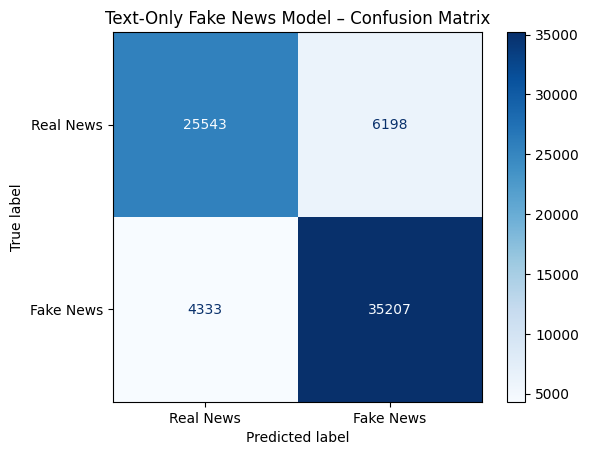

In [14]:
# --- Load text-only model ---
from tensorflow.keras.models import load_model

text_model = load_model(
    os.path.join(PROJECT_DIR, "models", "text_only_model.keras")
)
print("✅ Text-only model loaded")

# --- Load data ---
X_text = np.load(os.path.join(PROJECT_DIR, "data/processed", "text_emb.npy"))
df_final = pd.read_csv(os.path.join(PROJECT_DIR, "data/processed", "final_dataset.csv"))

# --- CLEAN labels ---
mask = df_final["2_way_label"].notna()   # keep only valid labels
df_clean = df_final[mask].reset_index(drop=True)

X_text_clean = X_text[mask.values]
y_clean = df_clean["2_way_label"].astype(int).values

print(f"Removed {len(df_final) - len(df_clean)} rows with NaN labels")
print("Samples used for evaluation:", len(y_clean))

# --- Predict ---
y_prob_text = text_model.predict(X_text_clean, batch_size=256).ravel()

# --- Evaluate ---
evaluate_binary_model(
    y_true=y_clean,
    y_prob=y_prob_text,
    title="Text-Only Fake News Model",
    class_names=["Real News", "Fake News"]
)


**IMAGE MODEL**

Using device: cpu
✅ Image authenticity model loaded
Classes: ['ai', 'authentic']

--- Image Authenticity Model Evaluation ---
Accuracy : 0.1703
ROC-AUC  : 0.0946

Classification Report:
              precision    recall  f1-score   support

          ai       0.13      0.12      0.12      2000
   authentic       0.20      0.22      0.21      2000

    accuracy                           0.17      4000
   macro avg       0.17      0.17      0.17      4000
weighted avg       0.17      0.17      0.17      4000



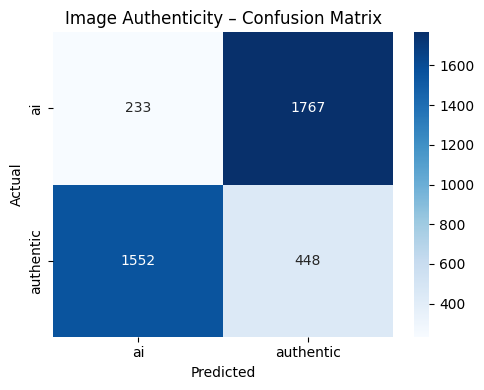

In [31]:
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# =========================
# CONFIG
# =========================
PROJECT_DIR = "/content/drive/MyDrive/final-multimodal-project"
MODEL_PATH = os.path.join(PROJECT_DIR, "models", "image_auth_model_torch.pth")
DATA_DIR = os.path.join(PROJECT_DIR, "data", "image_auth")

IMG_SIZE = 224
BATCH_SIZE = 32
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)

# =========================
# 1. Define SAME model architecture
# =========================
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# =========================
# 2. Load model
# =========================
model = SimpleCNN().to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

print("✅ Image authenticity model loaded")

# =========================
# 3. Dataset & loader
# =========================
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

dataset = ImageFolder(DATA_DIR, transform=transform)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

class_names = dataset.classes
print("Classes:", class_names)

# =========================
# 4. Inference
# =========================
y_true = []
y_prob = []
y_pred = []

with torch.no_grad():
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(imgs)
        probs = torch.sigmoid(outputs).squeeze(1)
        preds = (probs >= 0.5).long()

        y_true.extend(labels.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = np.array(y_pred)

# =========================
# 5. Metrics
# =========================
acc = accuracy_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)

print("\n--- Image Authenticity Model Evaluation ---")
print(f"Accuracy : {acc:.4f}")
print(f"ROC-AUC  : {auc:.4f}\n")

print("Classification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

# =========================
# 6. Confusion Matrix
# =========================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Image Authenticity – Confusion Matrix")
plt.tight_layout()
plt.show()


**FUSION MODEL**

✅ Fusion model loaded
Original shapes:
X_text: (71307, 768)
X_img : (71307, 1280)
df_final: (71307, 3)

After alignment:
X_text_aligned: (71281, 768)
X_img_aligned : (71281, 1280)
y_aligned     : (71281,)
X_fusion shape: (71281, 2048)
279/279 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step

--- Multimodal Fusion Model (Text + Image) ---
Accuracy : 0.8557
ROC-AUC  : 0.9322

Classification Report:
              precision    recall  f1-score   support

   Real News       0.83      0.85      0.84     31741
   Fake News       0.88      0.86      0.87     39540

    accuracy                           0.86     71281
   macro avg       0.85      0.86      0.85     71281
weighted avg       0.86      0.86      0.86     71281



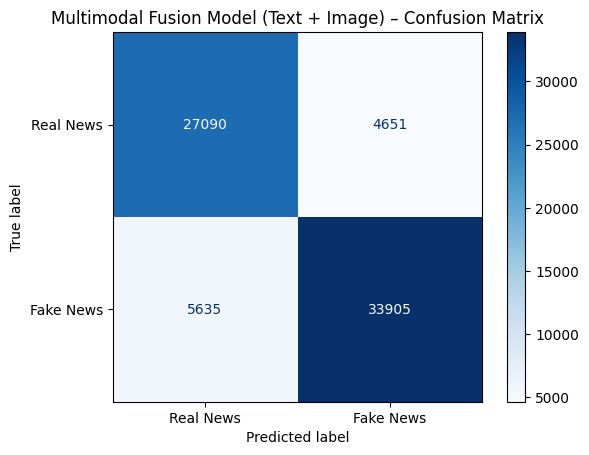

In [17]:
# --- Load fusion model ---
from tensorflow.keras.models import load_model
fusion_model = load_model(
    os.path.join(PROJECT_DIR, "models", "fusion_best_model.keras")
)
print("✅ Fusion model loaded")

# --- Load CORRECT embeddings (MobileNet-based) ---
X_text = np.load(os.path.join(PROJECT_DIR, "data/processed", "text_emb.npy"))
X_img  = np.load(os.path.join(PROJECT_DIR, "data/processed", "img_emb_mobilenet.npy"))

df_final = pd.read_csv(os.path.join(PROJECT_DIR, "data/processed", "final_dataset.csv"))

print("Original shapes:")
print("X_text:", X_text.shape)
print("X_img :", X_img.shape)
print("df_final:", df_final.shape)

# ---------------------------------------------------
# STEP 1: Clean labels
# ---------------------------------------------------
label_mask = df_final["2_way_label"].notna()
df_labeled = df_final[label_mask].reset_index(drop=True)

X_text_labeled = X_text[label_mask.values]
y_labeled = df_labeled["2_way_label"].astype(int).values

# ---------------------------------------------------
# STEP 2: Align text & image embeddings
# ---------------------------------------------------
min_len = min(len(X_img), len(X_text_labeled))

X_text_aligned = X_text_labeled[:min_len]
X_img_aligned  = X_img[:min_len]
y_aligned      = y_labeled[:min_len]

print("\nAfter alignment:")
print("X_text_aligned:", X_text_aligned.shape)
print("X_img_aligned :", X_img_aligned.shape)
print("y_aligned     :", y_aligned.shape)

# ---------------------------------------------------
# STEP 3: Fusion prediction
# ---------------------------------------------------
X_fusion = np.concatenate([X_text_aligned, X_img_aligned], axis=1)
print("X_fusion shape:", X_fusion.shape)  # MUST be (N, 2048)

y_prob_fusion = fusion_model.predict(X_fusion, batch_size=256).ravel()

# ---------------------------------------------------
# STEP 4: Evaluate
# ---------------------------------------------------
evaluate_binary_model(
    y_true=y_aligned,
    y_prob=y_prob_fusion,
    title="Multimodal Fusion Model (Text + Image)",
    class_names=["Real News", "Fake News"]
)
